# Lab 07：算帳與一個迷你的 IsoFLOP 實驗

對應講義：[第 07 課](../lessons/07_scaling_laws.md)

1. FLOPs：$6N$ 的估計 vs. PyTorch 的 FLOP 計數器；attention 項何時重要（式 7.1、7.2）
2. 這台 CPU 的 MFU（式 7.3）
3. 記憶體：模型狀態、activation（§2.2）
4. 迷你 IsoFLOP：三個算力預算 × 七種模型大小，找每個預算的最佳模型大小（§2.5）

CPU 約 80 分鐘，幾乎都在 §4（21 次完整訓練）。時間不夠的話，把 §4 的 `BUDGETS` 改成前兩個（約 25 分鐘），只是少一條曲線。

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
print(f"torch {torch.__version__}, {torch.get_num_threads()} threads")

torch 2.14.0+cu130, 4 threads


## 1. FLOPs

In [2]:
from lm_course.artifacts import base_model_config
from lm_course.model import GPT
from lm_course.scaling import matmul_parameters, measured_training_flops, training_flops_per_token

config = base_model_config()
model = GPT(config)
N = matmul_parameters(config)
est = training_flops_per_token(config)
idx = torch.randint(0, config.vocab_size, (4, config.context_length))
measured = measured_training_flops(model, idx) / idx.numel()
print(f"all parameters {model.num_parameters():,}; parameters in matrix multiplies N = {N:,}")
print(f"estimate per token: 6N = {est.matmul / 1e6:.1f} MFLOP, attention 12 L d T = {est.attention / 1e6:.1f} MFLOP")
print(f"PyTorch FlopCounterMode: {measured / 1e6:.1f} MFLOP per token")

all parameters 5,242,880; parameters in matrix multiplies N = 4,194,304
estimate per token: 6N = 25.2 MFLOP, attention 12 L d T = 3.1 MFLOP
PyTorch FlopCounterMode: 25.2 MFLOP per token


計數器量到的正好是 $6N$：PyTorch 在 CPU 上的 fused attention kernel 不在計數器的名單裡（`tests/test_scaling_and_systems.py` 另外驗證了 attention 項本身是 $12dT$）。
attention 項占多少，取決於 $T$ 和 $d$ 的比例（講義：約 $T / 6d$）：

In [3]:
from lm_course.model import gpt2_config, llama_style_config

rows = [
    ("this course (d=256)", base_model_config()),
    ("GPT-2 small", gpt2_config("gpt2")),
    ("7B-class (d=4096, L=32)", llama_style_config(n_layer=32, d_model=4096, n_head=32)),
]
print(f"{'model':<26}" + "".join(f"{'T=' + str(T):>10}" for T in (256, 1024, 8192, 131072)))
for name, cfg in rows:
    fracs = []
    for T in (256, 1024, 8192, 131072):
        e = training_flops_per_token(cfg, T)
        fracs.append(e.attention / e.total)
    print(f"{name:<26}" + "".join(f"{f:>10.0%}" for f in fracs))

model                          T=256    T=1024    T=8192  T=131072
this course (d=256)              11%       33%       80%       98%
GPT-2 small                       4%       13%       55%       95%
7B-class (d=4096, L=32)           1%        4%       24%       84%


## 2. MFU

用 2048×2048 的矩陣乘法量這台 CPU「實際能達到的峰值」，再和 Lab 06 設定的訓練吞吐量比較。

In [4]:
from lm_course.kernels import matmul_throughput
from lm_course.optim import build_optimizer
from lm_course.training import lm_loss

peak = matmul_throughput(2048)["gflops"]
opt = build_optimizer(model, "muon")
x = torch.randint(0, config.vocab_size, (32, config.context_length))
y = torch.randint(0, config.vocab_size, (32, config.context_length))
times = []
for step in range(6):
    start = time.perf_counter()
    opt.zero_grad()
    lm_loss(model(x), y).backward()
    opt.step()
    times.append(time.perf_counter() - start)
tokens_per_s = x.numel() / np.median(times[2:])
achieved = 6 * N * tokens_per_s / 1e9
print(f"matmul peak on this CPU: {peak:.0f} GFLOP/s")
print(f"training: {tokens_per_s:,.0f} tokens/s -> 6N x tokens/s = {achieved:.0f} GFLOP/s -> MFU {achieved / peak:.0%}")

matmul peak on this CPU: 370 GFLOP/s
training: 6,674 tokens/s -> 6N x tokens/s = 168 GFLOP/s -> MFU 45%


## 3. 記憶體

In [5]:
from lm_course.scaling import BYTES_PER_PARAM, saved_activation_bytes

print("model state (weights + gradients + optimizer):")
for name, n in [("this course", model.num_parameters()), ("GPT-2 small", 124.4e6), ("7B", 7e9), ("70B", 70e9)]:
    print(f"  {name:<12}" + "".join(f"  {k}: {v * n / 1e9:8.2f} GB" for k, v in BYTES_PER_PARAM.items() if k != "fp32 SGD"))

print("\nactivations saved for backward (fp32), this course's model:")
for B, T in [(1, 256), (8, 256), (32, 256), (32, 128), (32, 64)]:
    idx = torch.randint(0, config.vocab_size, (B, T))
    print(f"  batch {B:3d}, T {T:4d}: {saved_activation_bytes(model, idx) / 1e6:8.1f} MB")
print(f"model state for comparison (fp32 AdamW): {16 * model.num_parameters() / 1e6:.0f} MB")

model state (weights + gradients + optimizer):
  this course   fp32 AdamW:     0.08 GB  mixed-precision AdamW:     0.08 GB
  GPT-2 small   fp32 AdamW:     1.99 GB  mixed-precision AdamW:     1.99 GB
  7B            fp32 AdamW:   112.00 GB  mixed-precision AdamW:   112.00 GB
  70B           fp32 AdamW:  1120.00 GB  mixed-precision AdamW:  1120.00 GB

activations saved for backward (fp32), this course's model:
  batch   1, T  256:     24.8 MB
  batch   8, T  256:    197.7 MB


  batch  32, T  256:    790.5 MB


  batch  32, T  128:    395.3 MB


  batch  32, T   64:    197.6 MB
model state for comparison (fp32 AdamW): 84 MB


fp32 與混合精度的 AdamW 都是每個參數 16 bytes（講義 §2.2 的表）：混合精度省下的是 activation 與記憶體頻寬，不是模型狀態。

activation 和 batch 成正比、和 $T$ 大約成正比（PyTorch 的 fused attention 不存 $T \times T$ 的機率矩陣）；在 Lab 06 的設定（batch 32、T 256）下，activation 已經是模型狀態的好幾倍。

## 4. 迷你 IsoFLOP

固定算力預算 $C$，訓練不同大小的模型各 $D = C / 6N$ 個 token（$N$ 用參與矩陣乘法的參數，含 LM head——講義 §2.4 說明了為什麼要算全部），每個都跑完整的學習率排程（WSD，最後 40% 降到 0），量驗證 loss。
為了讓小模型也跑得動：context 128、batch 16。模型大小從 $d = 32$（1 層）到 $d = 256$（4 層）。

In [6]:
from lm_course.artifacts import course_tokenizer, course_tokens
from lm_course.model import nanochat_style_config
from lm_course.optim import wsd_schedule
from lm_course.training import train

tok = course_tokenizer()
train_tokens, val_tokens = course_tokens(tok)
T, B = 128, 16
SIZES = [(32, 1), (48, 2), (64, 2), (96, 3), (128, 4), (192, 4), (256, 4)]
BUDGETS = [3e12, 1e13, 3e13]
runs = []
start_all = time.perf_counter()
for C in BUDGETS:
    for d, L in SIZES:
        cfg = nanochat_style_config(vocab_size=tok.vocab_size, context_length=T, n_layer=L, n_head=max(1, d // 32), d_model=d)
        N = matmul_parameters(cfg)
        steps = int(C / (6 * N * B * T))
        if steps < 30:
            continue
        set_seed(0)
        m = GPT(cfg)
        r = train(m, train_tokens, val_tokens, num_steps=steps, batch_size=B, optimizer=build_optimizer(m, "muon", lr=3e-3, muon_lr=0.02),
                  schedule=wsd_schedule, warmup=min(50, steps // 10), eval_every=10**9, eval_batches=20, log_every=0)
        runs.append(dict(C=C, d=d, L=L, N=N, D=steps * B * T, loss=r.final_eval_loss))
        print(f"C={C:.0e}  d={d:3d} L={L}  N={N:>9,}  D={steps * B * T:>11,}  tokens/param {steps * B * T / N:7.1f}  val loss {r.final_eval_loss:.3f}")
print(f"total {(time.perf_counter() - start_all) / 60:.1f} min")

C=3e+12  d= 32 L=1  N=  143,360  D=  3,485,696  tokens/param    24.3  val loss 3.331


C=3e+12  d= 48 L=2  N=  251,904  D=  1,984,512  tokens/param     7.9  val loss 3.262


C=3e+12  d= 64 L=2  N=  360,448  D=  1,386,496  tokens/param     3.8  val loss 3.287


C=3e+12  d= 96 L=3  N=  724,992  D=    688,128  tokens/param     0.9  val loss 3.395


C=3e+12  d=128 L=4  N=1,310,720  D=    380,928  tokens/param     0.3  val loss 3.608


...

C=3e+13  d= 64 L=2  N=  360,448  D= 13,871,104  tokens/param    38.5  val loss 2.682


C=3e+13  d= 96 L=3  N=  724,992  D=  6,895,616  tokens/param     9.5  val loss 2.563


C=3e+13  d=128 L=4  N=1,310,720  D=  3,813,376  tokens/param     2.9  val loss 2.576


C=3e+13  d=192 L=4  N=2,555,904  D=  1,955,840  tokens/param     0.8  val loss 2.689


C=3e+13  d=256 L=4  N=4,194,304  D=  1,191,936  tokens/param     0.3  val loss 2.822
total 78.8 min


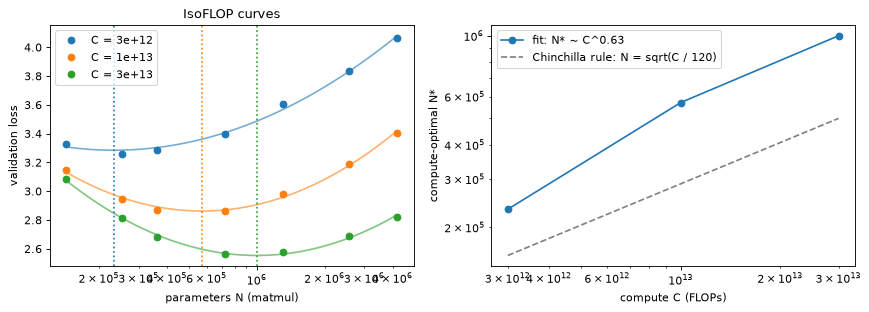

C = 3e+12: N* = 233,083, D* = C / 6N* = 2,145,163 tokens -> 9 tokens per parameter
C = 1e+13: N* = 571,319, D* = C / 6N* = 2,917,226 tokens -> 5 tokens per parameter
C = 3e+13: N* = 1,001,109, D* = C / 6N* = 4,994,464 tokens -> 5 tokens per parameter


In [7]:
from lm_course.scaling import fit_isoflop_minimum, fit_power_law

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
optima = []
for C in BUDGETS:
    rs = [r for r in runs if r["C"] == C]
    ns, losses = np.array([r["N"] for r in rs]), np.array([r["loss"] for r in rs])
    line, = axes[0].semilogx(ns, losses, "o", label=f"C = {C:.0e}")
    n_star = fit_isoflop_minimum(ns, losses)
    grid = np.logspace(np.log10(ns.min()), np.log10(ns.max()), 100)
    coef = np.polyfit(np.log(ns), losses, 2)
    axes[0].semilogx(grid, np.polyval(coef, np.log(grid)), "-", color=line.get_color(), alpha=0.6)
    axes[0].axvline(n_star, color=line.get_color(), ls=":")
    optima.append((C, n_star))
axes[0].set_xlabel("parameters N (matmul)")
axes[0].set_ylabel("validation loss")
axes[0].legend()
axes[0].set_title("IsoFLOP curves")
cs, ns_opt = np.array([c for c, _ in optima]), np.array([n for _, n in optima])
a, exponent = fit_power_law(cs, ns_opt)
axes[1].loglog(cs, ns_opt, "o-", label=f"fit: N* ~ C^{exponent:.2f}")
axes[1].loglog(cs, np.sqrt(cs / 120), "--", color="gray", label="Chinchilla rule: N = sqrt(C / 120)")
axes[1].set_xlabel("compute C (FLOPs)")
axes[1].set_ylabel("compute-optimal N*")
axes[1].legend()
plt.tight_layout()
plt.show()
for C, n in optima:
    print(f"C = {C:.0e}: N* = {n:,.0f}, D* = C / 6N* = {C / (6 * n):,.0f} tokens -> {C / (6 * n) / n:.0f} tokens per parameter")

**解讀**（小心）：

- 每條 IsoFLOP 曲線都有一個最低點：左邊的模型太小、裝不下；右邊的模型太大、看的資料太少。
- 算力越大，最佳的模型越大。這次擬合出 $N^* \propto C^{0.63}$，介於 Chinchilla 的 0.5 與 Kaplan 的 0.73 之間；最佳點每個參數只看 5–9 個 token，也和 Chinchilla 的約 20 不同。
- 這個實驗比真正的 scaling law 研究小 10 個數量級：只有三個預算、每點一個種子、TinyStories 的用字極有限、LM head 在小模型裡佔了大部分參數。**斜率的數值不可信，形狀才是重點。**

## 小結

- $6N$ 精確地描述了矩陣乘法的算力；長 context 時要加上 attention 項。
- 訓練記憶體＝16 bytes／參數的模型狀態＋與 batch、context 成正比的 activation。
- IsoFLOP 的做法：固定算力、掃模型大小、找最低點、再看最低點如何隨算力移動。

下一步：[第 08 課](../lessons/08_systems.md)。